In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,classification_report, accuracy_score

In [3]:
## load the data

df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\customer_churn_project\telecom_customers.xls",
    sep="\t"
)

In [4]:
df.head()

,customer_id,monthly_spend,total_calls,data_usage_gb,customer_service_calls,tenure_months,contract_type,churned
0,1001,771,388,9.4,5,11,Month-to-month,1
1,1002,1072,299,5.3,6,8,Month-to-month,1
2,1003,3437,637,22.0,1,67,Two year,0
3,1004,952,435,4.2,6,6,Month-to-month,1
4,1005,887,407,6.1,9,12,Month-to-month,1


### Explanatory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1000 non-null   int64  
 1   monthly_spend           1000 non-null   int64  
 2   total_calls             1000 non-null   int64  
 3   data_usage_gb           1000 non-null   float64
 4   customer_service_calls  1000 non-null   int64  
 5   tenure_months           1000 non-null   int64  
 6   contract_type           1000 non-null   object 
 7   churned                 1000 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 62.6+ KB


In [6]:
df.columns

Index(['customer_id', 'monthly_spend', 'total_calls', 'data_usage_gb',
       'customer_service_calls', 'tenure_months', 'contract_type', 'churned'],
      dtype='object')

In [8]:
df.describe()

,customer_id,monthly_spend,total_calls,data_usage_gb,customer_service_calls,tenure_months,churned
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,1521.883000,457.06700,15.183000,4.059000,20.207000,0.437000
std,288.819436,745.184291,158.92277,8.083925,2.850552,18.062403,0.496263
min,1001.000000,700.000000,200.00000,4.000000,0.000000,1.000000,0.000000
25%,1250.750000,956.000000,335.00000,8.600000,1.000000,6.000000,0.000000
50%,1500.500000,1208.500000,429.50000,13.100000,4.000000,12.000000,0.000000
75%,1750.250000,1877.250000,572.25000,20.200000,6.000000,30.000000,1.000000
max,2000.000000,3496.000000,799.00000,34.900000,9.000000,72.000000,1.000000


In [9]:
df.describe(include="all")

,customer_id,monthly_spend,total_calls,data_usage_gb,customer_service_calls,tenure_months,contract_type,churned
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Month-to-month,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,497,NaN
mean,1500.500000,1521.883000,457.06700,15.183000,4.059000,20.207000,NaN,0.437000
std,288.819436,745.184291,158.92277,8.083925,2.850552,18.062403,NaN,0.496263
min,1001.000000,700.000000,200.00000,4.000000,0.000000,1.000000,NaN,0.000000
25%,1250.750000,956.000000,335.00000,8.600000,1.000000,6.000000,NaN,0.000000
50%,1500.500000,1208.500000,429.50000,13.100000,4.000000,12.000000,NaN,0.000000
75%,1750.250000,1877.250000,572.25000,20.200000,6.000000,30.000000,NaN,1.000000


In [10]:
## Cleaning the data
df.isnull().sum()

customer_id               0
monthly_spend             0
total_calls               0
data_usage_gb             0
customer_service_calls    0
tenure_months             0
contract_type             0
churned                   0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df['contract_type'].value_counts()

contract_type
Month-to-month    497
One year          298
Two year          205
Name: count, dtype: int64

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

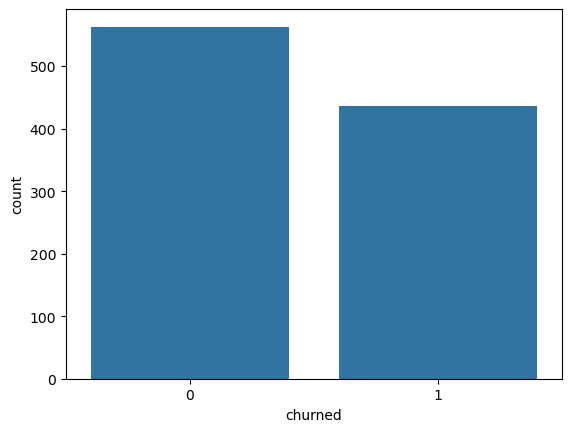

In [14]:
sns.countplot(x='churned', data=df)
plt.show()

In [42]:
df.columns

Index(['customer_id', 'monthly_spend', 'total_calls', 'data_usage_gb',
       'customer_service_calls', 'tenure_months', 'contract_type', 'churned'],
      dtype='object')

In [16]:
numerical_cols = ['monthly_spend', 'total_calls', 'data_usage_gb', 'customer_service_calls', 'tenure_months']

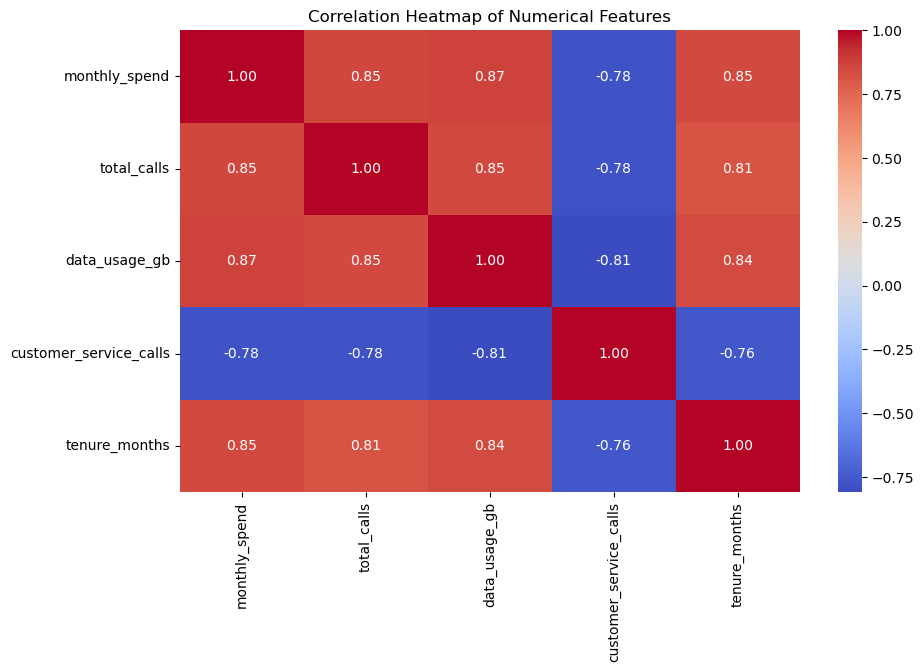

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

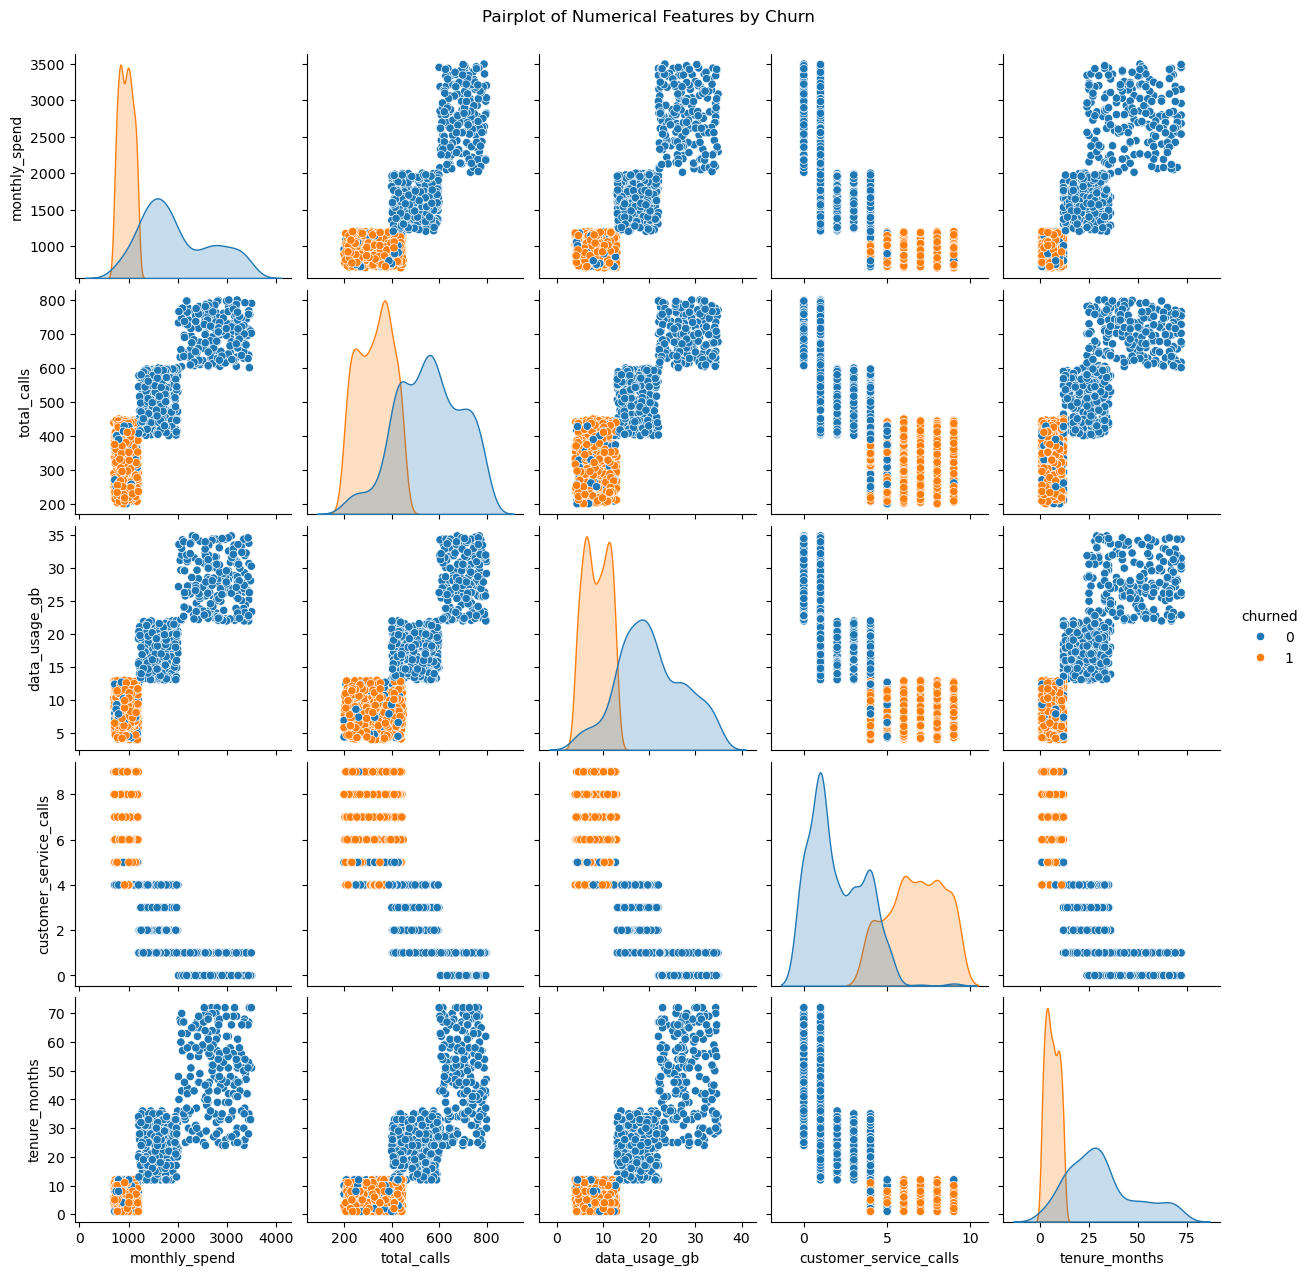

In [18]:
sns.pairplot(df[numerical_cols + ['churned']], hue='churned', diag_kind='kde')
plt.suptitle("Pairplot of Numerical Features by Churn", y=1.02)
plt.show()

In [19]:
categorical_cols = ['contract_type', 'churned']

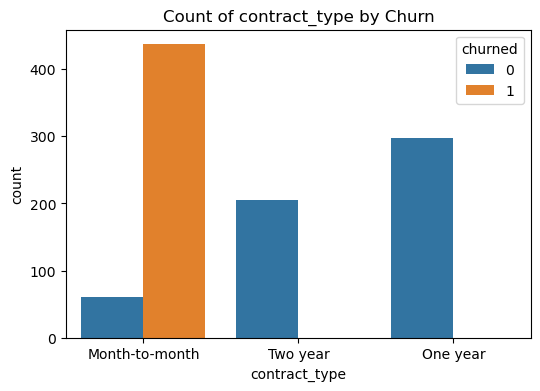

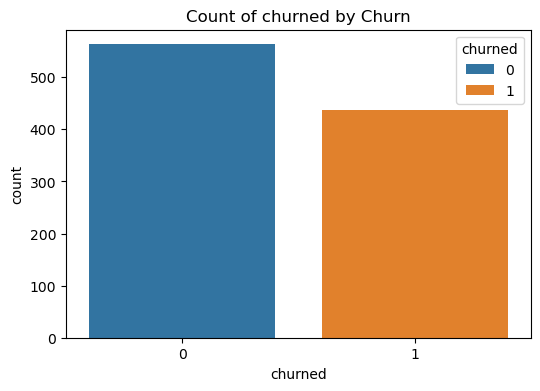

In [20]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='churned')
    plt.title(f"Count of {col} by Churn")
    plt.show()

In [21]:
## Preare the data for modeling
df_encoded = pd.get_dummies(df, columns=['contract_type'], drop_first=False)

In [22]:
df_encoded = df_encoded.drop('customer_id', axis=1)

In [23]:
#Separate features and target variable
X = df_encoded.drop('churned', axis=1)
y = df_encoded['churned']

In [24]:
#split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2,
                                                     random_state=42,
                                                     stratify=y
                                                     )

In [25]:
##Training a logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test) #make a prediction on the test set
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       113
           1       0.86      0.95      0.90        87

    accuracy                           0.91       200
   macro avg       0.91      0.92      0.91       200
weighted avg       0.92      0.91      0.91       200



In [26]:
y_pred_proba = model.predict_proba(x_test)[:, 1] # Get the predicted probabilities for the positive class-
#those who are likely to churn


In [27]:
comparison_df = pd.DataFrame({
    'Actual_churn': y_test.values[:10],
    'Predicted_churn': y_pred[:10],
    'churn_probability': [f"{prob:.1f}" for prob in y_pred_proba[:10]]
})
print(comparison_df)

   Actual_churn  Predicted_churn churn_probability
0             1                1               0.9
1             0                0               0.0
2             1                1               1.0
3             1                1               1.0
4             1                1               1.0
5             1                1               1.0
6             0                0               0.0
7             1                1               1.0
8             1                1               1.0
9             1                1               1.0
